In [1]:
import os
import re
import random

In [2]:
import pandas as pd

data = pd.read_csv('competition_data.csv')
submission = pd.read_csv('submission.csv')
submission_aux = pd.read_csv('submission.csv')

In [3]:
data

,Unnamed: 0,ts,username,platform,conn_country,user_agent_decrypted,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,shuffle,TARGET
0,110163,2018-03-11T05:05:45Z,11145402699,"iOS 11.0 (iPhone8,1)",AR,NaN,Crazy For U,Big Time Rush,24/seven,spotify:track:3jFfr89lnSmb4QBtfG8JBP,clickrow,False,False
1,66026,2023-06-05T10:42:33Z,11145402699,ios,AR,unknown,Nada Personal - Remasterizado 2007,Soda Stereo,Me Verás Volver (Hits & Más),spotify:track:09TTeexnlKewZdjOak2sV2,trackdone,True,False
2,116790,2018-07-01T02:04:51Z,11145402699,"iOS 11.0 (iPhone8,1)",AR,unknown,Good Times,CHIC,Risqué,spotify:track:0G3fbPbE1vGeABDEZF0jeG,trackdone,True,True
3,18431,2019-09-08T04:58:07Z,11145402699,"iOS 12.4 (iPhone8,1)",AR,unknown,Verano del 92,Los Piojos,3er Arco,spotify:track:1NXvuBAq48QrxRFQZVmORQ,trackdone,False,True
4,82941,2017-07-13T18:13:52Z,11145402699,"iOS 11.0 (iPhone8,1)",AR,NaN,Simpatico,Ekko Park,Simpatico,spotify:track:2gYJY0sIx1ErgTIha2nPRg,trackdone,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
100139,78756,2017-04-06T20:31:14Z,11145402699,"iOS 10.2.1 (iPad6,8,1)",AR,NaN,Losing My Religion,R.E.M.,In Time: The Best Of R.E.M. 1988-2003,spotify:track:12axV6NUqaYH3yFUWwArzr,trackdone,True,False
100140,12585,2021-11-03T21:06:07Z,11145402699,"iOS 15.1 (iPhone12,3)",AR,unknown,Cerca De La Revolucion,Charly García,Piano Bar,spotify:track:66grIvFLGrI4tNhggO2DAd,trackdone,True,False
100141,93960,2022-01-14T01:13:42Z,11145402699,"iOS 15.2 (iPhone12,3)",AR,unknown,A Los Jóvenes De Ayer - Remastered 2012,Serú Girán,Bicicleta,spotify:track:6YAl320SfxLO4rVIZTFKqG,trackdone,True,False
100142,74339,2024-05-01T17:51:16Z,11145402699,ios,AR,NaN,heat not hot,Serengeti,heat not hot,spotify:track:0rKLO1hXpmoIthQgJKoczN,trackdone,True,False


In [4]:
#eliminamos datos particulares de Chona, son siempre los mismos, y los que consideramos irrelevanets
data = data.drop(columns=['username', 'conn_country', 'user_agent_decrypted'])
submission = submission.drop(columns=['username', 'conn_country', 'user_agent_decrypted'])

In [5]:
# del timestamp, solo nos interesa distinguir hora, el dia de la semana, el mes y el año

data['ts'] = pd.to_datetime(data['ts'])
submission['ts'] = pd.to_datetime(submission['ts'])

# Extraer la hora
data['hour'] = data['ts'].dt.hour
submission['hour'] = submission['ts'].dt.hour

# Extraer el día de la semana (0 es lunes, 6 es domingo)
data['day_of_week'] = data['ts'].dt.dayofweek
submission['day_of_week'] = submission['ts'].dt.dayofweek

# Extraer el mes
data['month'] = data['ts'].dt.month
submission['month'] = submission['ts'].dt.month

# Extraer el año
data['year'] = data['ts'].dt.year - 2000
submission['year'] = submission['ts'].dt.year - 2000

In [6]:
# del dispositivo, solo queremos saber si se reprodujo en celular (iphone) o no
data['is_iphone'] = data['platform'].apply(lambda x: 1 if ('ios' in x or 'iOS' in x) else 0)
submission['is_iphone'] = submission['platform'].apply(lambda x: 1 if ('ios' in x or 'iOS' in x) else 0)

# dropeamos platform
data = data.drop(columns=['platform'])
submission = submission.drop(columns=['platform'])

In [7]:
data

,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,shuffle,TARGET,hour,day_of_week,month,year,is_iphone
0,110163,2018-03-11 05:05:45+00:00,Crazy For U,Big Time Rush,24/seven,spotify:track:3jFfr89lnSmb4QBtfG8JBP,clickrow,False,False,5,6,3,18,1
1,66026,2023-06-05 10:42:33+00:00,Nada Personal - Remasterizado 2007,Soda Stereo,Me Verás Volver (Hits & Más),spotify:track:09TTeexnlKewZdjOak2sV2,trackdone,True,False,10,0,6,23,1
2,116790,2018-07-01 02:04:51+00:00,Good Times,CHIC,Risqué,spotify:track:0G3fbPbE1vGeABDEZF0jeG,trackdone,True,True,2,6,7,18,1
3,18431,2019-09-08 04:58:07+00:00,Verano del 92,Los Piojos,3er Arco,spotify:track:1NXvuBAq48QrxRFQZVmORQ,trackdone,False,True,4,6,9,19,1
4,82941,2017-07-13 18:13:52+00:00,Simpatico,Ekko Park,Simpatico,spotify:track:2gYJY0sIx1ErgTIha2nPRg,trackdone,True,False,18,3,7,17,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100139,78756,2017-04-06 20:31:14+00:00,Losing My Religion,R.E.M.,In Time: The Best Of R.E.M. 1988-2003,spotify:track:12axV6NUqaYH3yFUWwArzr,trackdone,True,False,20,3,4,17,1
100140,12585,2021-11-03 21:06:07+00:00,Cerca De La Revolucion,Charly García,Piano Bar,spotify:track:66grIvFLGrI4tNhggO2DAd,trackdone,True,False,21,2,11,21,1
100141,93960,2022-01-14 01:13:42+00:00,A Los Jóvenes De Ayer - Remastered 2012,Serú Girán,Bicicleta,spotify:track:6YAl320SfxLO4rVIZTFKqG,trackdone,True,False,1,4,1,22,1
100142,74339,2024-05-01 17:51:16+00:00,heat not hot,Serengeti,heat not hot,spotify:track:0rKLO1hXpmoIthQgJKoczN,trackdone,True,False,17,2,5,24,1


Análisis Exploratorio de Datos

In [ ]:
data.describe()  # Estadísticas de columnas numéricas

In [24]:
data.isnull().sum()       # Conteo de valores nulos por columna

Unnamed: 0                             0
ts                                     0
master_metadata_track_name           973
master_metadata_album_artist_name    973
master_metadata_album_album_name     973
spotify_track_uri                    973
reason_start                           4
shuffle                                0
TARGET                                 0
hour                                   0
day_of_week                            0
month                                  0
year                                   0
is_iphone                              0
dtype: int64

In [25]:
data.duplicated().sum()   # Filas duplicadas

np.int64(0)

In [27]:
data['reason_start'].value_counts()

reason_start
fwdbtn        39765
trackdone     32827
clickrow      17796
playbtn        5548
backbtn        2572
appload         813
trackerror      422
remote          306
unknown          91
Name: count, dtype: int64

In [28]:
data['reason_start'].value_counts(normalize=True)  # proporciones

reason_start
fwdbtn        0.397094
trackdone     0.327811
clickrow      0.177711
playbtn       0.055402
backbtn       0.025684
appload       0.008119
trackerror    0.004214
remote        0.003056
unknown       0.000909
Name: proportion, dtype: float64

<Axes: >

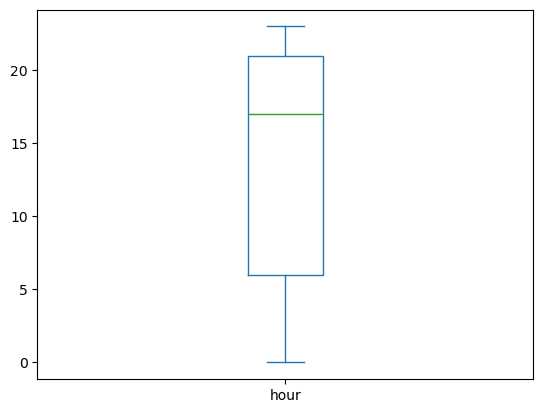

In [31]:
data['hour'].plot(kind='box')     

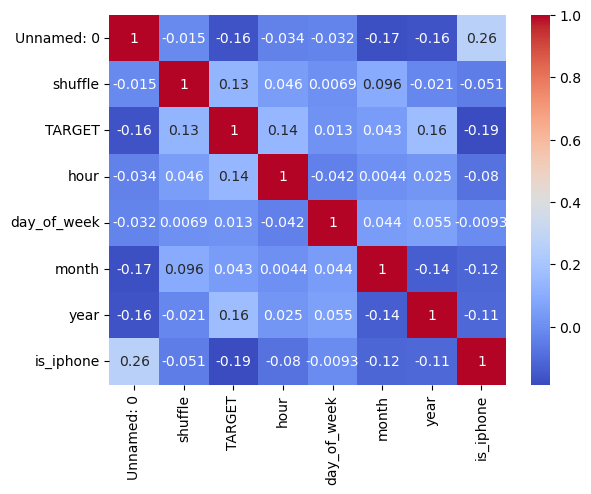

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [8]:
#antes de seguir con operaciones por columna, separamos validation y train
# la idea es que train tenga 80% de datos de cada año, y val el resto
train_parts = []
val_parts = []

for year, group in data.groupby('year'):
    group = group.sort_values('ts')  # mantener orden cronológico dentro del año
    split_idx = int(len(group) * 0.8)
    train_parts.append(group.iloc[:split_idx])
    val_parts.append(group.iloc[split_idx:])

train_data = pd.concat(train_parts).sort_values('ts').reset_index(drop=True)
val_data = pd.concat(val_parts).sort_values('ts').reset_index(drop=True)

In [9]:
train_data

,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,shuffle,TARGET,hour,day_of_week,month,year,is_iphone
0,74917,2014-06-27 18:01:16+00:00,Algo Demencial,Los Tipitos,Push,spotify:track:0rqD0zvqI4GrvyUxyQ7Ij3,fwdbtn,True,True,18,4,6,14,1
1,74918,2014-06-29 20:10:10+00:00,Iron Man - Live,Black Sabbath,Past Lives,spotify:track:1XtZ3GROvmy4JrT6uMvsD8,NaN,False,True,20,6,6,14,1
2,74919,2014-06-29 20:10:54+00:00,Sultans Of Swing,Dire Straits,Dire Straits,spotify:track:3LTMnFa0hhwisyq6ILahyj,fwdbtn,False,True,20,6,6,14,1
3,74920,2014-06-29 20:11:16+00:00,Fortunate Son,Creedence Clearwater Revival,Willy And The Poor Boys,spotify:track:7I2lPuuiOkpKtZlhr4zUpT,fwdbtn,False,True,20,6,6,14,1
4,74921,2014-09-04 21:46:24+00:00,"Comptine d'un autre été, l'après-midi",Yann Tiersen,Amelie from Montmartre,spotify:track:2AkcjsKlRbIBYGAgpQVFii,NaN,False,True,21,3,9,14,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80105,74211,2024-04-23 18:10:42+00:00,Redbone,Childish Gambino,"""Awaken, My Love!""",spotify:track:0WtDGnWL2KrMCk0mI1Gpwz,trackdone,True,False,18,1,4,24,1
80106,74212,2024-04-23 18:11:29+00:00,Thunder,Imagine Dragons,Evolve,spotify:track:1zB4vmk8tFRmM9UULNzbLB,trackdone,True,True,18,1,4,24,1
80107,74213,2024-04-23 18:11:31+00:00,Pump Up The Jam - Edit,Technotronic,Best Of,spotify:track:0UAEHlFR79k9CJvknSGUNf,fwdbtn,True,True,18,1,4,24,1
80108,74214,2024-04-23 18:11:33+00:00,Young Folks,Peter Bjorn and John,Writer's Block,spotify:track:4dyx5SzxPPaD8xQIid5Wjj,fwdbtn,True,True,18,1,4,24,1


In [10]:
submission = submission.sort_values('ts').reset_index(drop=True)

In [11]:
# # Aplicar One-Hot Encoding a razon de reproduccion
# train_reason_start_encoded = pd.get_dummies(train_data['reason_start'], prefix='reason', dummy_na=False)
# val_reason_start_encoded = pd.get_dummies(val_data['reason_start'], prefix='reason', dummy_na=False)
# submission_reason_start_encoded = pd.get_dummies(submission['reason_start'], prefix='reason', dummy_na=False)

# # Concatenar el DataFrame original con el nuevo DataFrame de variables codificadas
# train_data = pd.concat([train_data, train_reason_start_encoded], axis=1)
# val_data = pd.concat([val_data, val_reason_start_encoded], axis=1)
# submission = pd.concat([submission, submission_reason_start_encoded], axis=1)

# # Dropear la columna original
# train_data = train_data.drop(columns=['reason_start'])
# val_data = val_data.drop(columns=['reason_start'])
# submission = submission.drop(columns=['reason_start'])

In [12]:
# #al analizar los df, vemos que a validation le falta columna reason_unknown
# val_data['reason_unknown'] = False
# val_data

In [13]:
# La idea es primero, simplificar los motivos de inicio de la canción, y luego hacer One-Hot Encoding sobre la columna simplificada
# Definir una función para simplificar los motivos

def simplify_reason(reason):
    if reason == 'fwdbtn':
        return 'fwdbtn'
    elif reason == 'trackdone':
        return 'trackdone'
    else:
        return 'other'

# Aplicar la simplificación

train_data['reason_start'] = train_data['reason_start'].apply(simplify_reason)
val_data['reason_start'] = val_data['reason_start'].apply(simplify_reason)
submission['reason_start'] = submission['reason_start'].apply(simplify_reason)

In [14]:
# Ahora hacer One-Hot Encoding sobre la columna simplificada

train_encoded_reasons = pd.get_dummies(train_data['reason_start'], prefix='reason')
val_encoded_reasons = pd.get_dummies(val_data['reason_start'], prefix='reason')
submission_encoded_reasons = pd.get_dummies(submission['reason_start'], prefix='reason')

# # Asegurar que ambas tengan las mismas columnas (por si en validación falta alguna categoría)

for col in ['reason_fwdbtn', 'reason_trackdone', 'reason_other']:
    if col not in train_encoded_reasons:
        train_encoded_reasons[col] = 0
    if col not in val_encoded_reasons:
        val_encoded_reasons[col] = 0
    if col not in submission_encoded_reasons:
        submission_encoded_reasons[col] = 0

# # Asegurar el mismo orden de columnas

train_encoded_reasons = train_encoded_reasons[['reason_fwdbtn', 'reason_trackdone', 'reason_other']]
val_encoded_reasons = val_encoded_reasons[['reason_fwdbtn', 'reason_trackdone', 'reason_other']]
submission_encoded_reasons = submission_encoded_reasons[['reason_fwdbtn', 'reason_trackdone', 'reason_other']]

# # convertir a entero los bools

for col in train_encoded_reasons.columns:
    train_encoded_reasons[col] = train_encoded_reasons[col].astype(int)
    val_encoded_reasons[col] = val_encoded_reasons[col].astype(int)
    submission_encoded_reasons[col] = submission_encoded_reasons[col].astype(int)
    

# # Concatenar al DataFrame original

train_data = pd.concat([train_data.reset_index(drop=True), train_encoded_reasons.reset_index(drop=True)], axis=1)
val_data = pd.concat([val_data.reset_index(drop=True), val_encoded_reasons.reset_index(drop=True)], axis=1)
submission = pd.concat([submission.reset_index(drop=True), submission_encoded_reasons.reset_index(drop=True)], axis=1)
train_data = train_data.drop(columns=['reason_start', 'reason_other'])
val_data = val_data.drop(columns=['reason_start', 'reason_other'])
submission = submission.drop(columns=['reason_start', 'reason_other'])

In [15]:
#submission

In [16]:
#pip install spotipy
import spotipy
from spotipy.oauth2 import SpotifyOAuth
import webbrowser

In [17]:
def get_spotify_auth():
    # Configura el objeto SpotifyOAuth
    auth_manager = SpotifyOAuth(
        client_id="bd28f888d5594351a74597b8c4750b07",
        client_secret="2ad3d9ea7c00425792697d028c5afbd5",
        redirect_uri="http://127.0.0.1:1234/",
        scope="user-top-read",
        open_browser=False
    )
    if auth_manager != None:
        return auth_manager
    else:
        # Si no se puede obtener el token, abre el navegador para la autenticación
        print("Error al obtener el token")

def chunk_list(lst, size):
    """Divide la lista 'lst' en sublistas de tamaño 'size'."""
    return [lst[i:i + size] for i in range(0, len(lst), size)]


In [18]:
def get_songs_durations(df):
    manager = get_spotify_auth()
    sp = spotipy.Spotify(auth_manager=manager)
    # Obtener la duración de las canciones
    # Obtener los URIs únicos y válidos
    tracks = df['spotify_track_uri'].dropna().unique()  # Elimina NaN directamente
    tracks = [uri for uri in tracks if isinstance(uri, str)]  # Filtra que sean strings

    # Dividir en chunks de hasta 50 elementos
    chunks = chunk_list(tracks, 50)
    uri_to_duration = {}
    for i, chunk in enumerate(chunks):
        print(i)
        try:
            tracks_info = sp.tracks(chunk)  # Consulta a la API
            for track in tracks_info.get('tracks', []):
                if track:
                    uri = track.get('uri')
                    duration = track.get('duration_ms')
                    uri_to_duration[uri] = duration
                else:
                    print("⚠️  Track no encontrado o no disponible.")
        except Exception as e:
            print(f"❌ Error al procesar el chunk {i + 1}: {e}")
    return uri_to_duration


In [19]:
# # Definimos funciones auxiliares que buscan en el diccionario por cada fila
# uri_to_duration_data = get_songs_durations(data)
# uri_to_duration_sub = get_songs_durations(submission)
# # Unimos los dos diccionarios
# diccionario = {**uri_to_duration_data, **uri_to_duration_sub}

# def get_duration(uri):
#     return diccionario.get(uri, None)

In [20]:
# Creamos las nuevas columnas aplicando la funcion
train_data['duration_ms'] = train_data['spotify_track_uri'].apply(get_duration)
val_data['duration_ms'] = val_data['spotify_track_uri'].apply(get_duration)
submission['duration_ms'] = submission['spotify_track_uri'].apply(get_duration)

NameError: name 'get_duration' is not defined

In [ ]:
train_data

,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,shuffle,TARGET,hour,day_of_week,month,year,is_iphone,reason_fwdbtn,reason_trackdone,duration_ms
0,74917,2014-06-27 18:01:16+00:00,Algo Demencial,Los Tipitos,Push,spotify:track:0rqD0zvqI4GrvyUxyQ7Ij3,True,True,18,4,6,14,1,1,0,344466.0
1,74918,2014-06-29 20:10:10+00:00,Iron Man - Live,Black Sabbath,Past Lives,spotify:track:1XtZ3GROvmy4JrT6uMvsD8,False,True,20,6,6,14,1,0,0,385880.0
2,74919,2014-06-29 20:10:54+00:00,Sultans Of Swing,Dire Straits,Dire Straits,spotify:track:3LTMnFa0hhwisyq6ILahyj,False,True,20,6,6,14,1,1,0,348624.0
3,74920,2014-06-29 20:11:16+00:00,Fortunate Son,Creedence Clearwater Revival,Willy And The Poor Boys,spotify:track:7I2lPuuiOkpKtZlhr4zUpT,False,True,20,6,6,14,1,1,0,140773.0
4,74921,2014-09-04 21:46:24+00:00,"Comptine d'un autre été, l'après-midi",Yann Tiersen,Amelie from Montmartre,spotify:track:2AkcjsKlRbIBYGAgpQVFii,False,True,21,3,9,14,1,0,0,140733.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80105,74211,2024-04-23 18:10:42+00:00,Redbone,Childish Gambino,"""Awaken, My Love!""",spotify:track:0WtDGnWL2KrMCk0mI1Gpwz,True,False,18,1,4,24,1,0,1,326933.0
80106,74212,2024-04-23 18:11:29+00:00,Thunder,Imagine Dragons,Evolve,spotify:track:1zB4vmk8tFRmM9UULNzbLB,True,True,18,1,4,24,1,0,1,187146.0
80107,74213,2024-04-23 18:11:31+00:00,Pump Up The Jam - Edit,Technotronic,Best Of,spotify:track:0UAEHlFR79k9CJvknSGUNf,True,True,18,1,4,24,1,1,0,215040.0
80108,74214,2024-04-23 18:11:33+00:00,Young Folks,Peter Bjorn and John,Writer's Block,spotify:track:4dyx5SzxPPaD8xQIid5Wjj,True,True,18,1,4,24,1,1,0,276693.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
# Calculamos las proporciones para cada canción, artista y álbum
train_data['track_prop'] = train_data.groupby('master_metadata_track_name')['master_metadata_track_name'].transform('count')/len(train_data)
train_data['artist_prop'] = train_data.groupby('master_metadata_album_artist_name')['master_metadata_album_artist_name'].transform('count')/len(train_data)
train_data['album_prop'] = train_data.groupby('master_metadata_album_album_name')['master_metadata_album_album_name'].transform('count')/len(train_data)

val_data['track_prop'] = val_data.groupby('master_metadata_track_name')['master_metadata_track_name'].transform('count')/len(val_data)
val_data['artist_prop'] = val_data.groupby('master_metadata_album_artist_name')['master_metadata_album_artist_name'].transform('count')/len(val_data)
val_data['album_prop'] = val_data.groupby('master_metadata_album_album_name')['master_metadata_album_album_name'].transform('count')/len(val_data)

submission['track_prop'] = submission.groupby('master_metadata_track_name')['master_metadata_track_name'].transform('count')/len(submission)
submission['artist_prop'] = submission.groupby('master_metadata_album_artist_name')['master_metadata_album_artist_name'].transform('count')/len(submission)
submission['album_prop'] = submission.groupby('master_metadata_album_album_name')['master_metadata_album_album_name'].transform('count')/len(submission)

In [ ]:
train_data

,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,shuffle,TARGET,hour,day_of_week,month,year,is_iphone,reason_fwdbtn,reason_trackdone,duration_ms,track_prop,artist_prop,album_prop
0,74917,2014-06-27 18:01:16+00:00,Algo Demencial,Los Tipitos,Push,spotify:track:0rqD0zvqI4GrvyUxyQ7Ij3,True,True,18,4,6,14,1,1,0,344466.0,0.000012,0.002135,0.000687
1,74918,2014-06-29 20:10:10+00:00,Iron Man - Live,Black Sabbath,Past Lives,spotify:track:1XtZ3GROvmy4JrT6uMvsD8,False,True,20,6,6,14,1,0,0,385880.0,0.000025,0.000487,0.000025
2,74919,2014-06-29 20:10:54+00:00,Sultans Of Swing,Dire Straits,Dire Straits,spotify:track:3LTMnFa0hhwisyq6ILahyj,False,True,20,6,6,14,1,1,0,348624.0,0.000374,0.000911,0.000275
3,74920,2014-06-29 20:11:16+00:00,Fortunate Son,Creedence Clearwater Revival,Willy And The Poor Boys,spotify:track:7I2lPuuiOkpKtZlhr4zUpT,False,True,20,6,6,14,1,1,0,140773.0,0.000412,0.001361,0.000699
4,74921,2014-09-04 21:46:24+00:00,"Comptine d'un autre été, l'après-midi",Yann Tiersen,Amelie from Montmartre,spotify:track:2AkcjsKlRbIBYGAgpQVFii,False,True,21,3,9,14,1,0,0,140733.0,0.000025,0.000025,0.000025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80105,74211,2024-04-23 18:10:42+00:00,Redbone,Childish Gambino,"""Awaken, My Love!""",spotify:track:0WtDGnWL2KrMCk0mI1Gpwz,True,False,18,1,4,24,1,0,1,326933.0,0.002259,0.012208,0.005530
80106,74212,2024-04-23 18:11:29+00:00,Thunder,Imagine Dragons,Evolve,spotify:track:1zB4vmk8tFRmM9UULNzbLB,True,True,18,1,4,24,1,0,1,187146.0,0.000836,0.008364,0.002933
80107,74213,2024-04-23 18:11:31+00:00,Pump Up The Jam - Edit,Technotronic,Best Of,spotify:track:0UAEHlFR79k9CJvknSGUNf,True,True,18,1,4,24,1,1,0,215040.0,0.001086,0.001086,0.001098
80108,74214,2024-04-23 18:11:33+00:00,Young Folks,Peter Bjorn and John,Writer's Block,spotify:track:4dyx5SzxPPaD8xQIid5Wjj,True,True,18,1,4,24,1,1,0,276693.0,0.001348,0.001373,0.001361


In [ ]:
# Elegimos las columnas a usar para la primera combinación polinómica
def comb_polinom(df, cols):
    # Crear combinaciones polinómicas de las columnas especificadas
    poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    poly_features = poly.fit_transform(df[cols])
    
    # Crear un DataFrame con los nombres de las nuevas columnas
    feature_names = poly.get_feature_names_out(cols)
    poly_df = pd.DataFrame(poly_features, columns=feature_names, index=df.index)
    poly_df = poly_df.drop(columns=cols)  # Eliminar las columnas originales
    
    # Concatenar el DataFrame original con el nuevo DataFrame de características polinómicas
    return pd.concat([df.reset_index(drop=True), poly_df.reset_index(drop=True)], axis=1)

In [ ]:
train_data = comb_polinom(train_data, ['hour', 'day_of_week'])
val_data = comb_polinom(val_data, ['hour', 'day_of_week'])
submission = comb_polinom(submission, ['hour', 'day_of_week'])

In [ ]:
#skips seguidos

def calculate_skips_seguidos(df):
    # Inicializamos la columna en 0
    df['skips_seguidos'] = 0
    
    # Iteramos desde la segunda fila
    for i in range(1, len(df)):
        try:
            ts_anterior = df.at[i-1, 'ts']
            duracion_anterior = pd.Timedelta(milliseconds=df.at[i-1, 'duration_ms'])
            ts_actual = df.at[i, 'ts']
            
            if ts_anterior + duracion_anterior > ts_actual:
                df.at[i, 'skips_seguidos'] = df.at[i-1, 'skips_seguidos'] + 1
        except:
            # Si hay un error, lo ignoramos y continuamos
            pass

calculate_skips_seguidos(train_data)
calculate_skips_seguidos(val_data)
calculate_skips_seguidos(submission)

In [ ]:
#!pip install xgboost
print(train_data['skips_seguidos'].max())
train_data

278


,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,shuffle,TARGET,hour,day_of_week,...,year,is_iphone,reason_fwdbtn,reason_trackdone,duration_ms,track_prop,artist_prop,album_prop,hour day_of_week,skips_seguidos
0,74917,2014-06-27 18:01:16+00:00,Algo Demencial,Los Tipitos,Push,spotify:track:0rqD0zvqI4GrvyUxyQ7Ij3,True,True,18,4,...,14,1,1,0,344466.0,0.000012,0.002135,0.000687,72.0,0
1,74918,2014-06-29 20:10:10+00:00,Iron Man - Live,Black Sabbath,Past Lives,spotify:track:1XtZ3GROvmy4JrT6uMvsD8,False,True,20,6,...,14,1,0,0,385880.0,0.000025,0.000487,0.000025,120.0,0
2,74919,2014-06-29 20:10:54+00:00,Sultans Of Swing,Dire Straits,Dire Straits,spotify:track:3LTMnFa0hhwisyq6ILahyj,False,True,20,6,...,14,1,1,0,348624.0,0.000374,0.000911,0.000275,120.0,1
3,74920,2014-06-29 20:11:16+00:00,Fortunate Son,Creedence Clearwater Revival,Willy And The Poor Boys,spotify:track:7I2lPuuiOkpKtZlhr4zUpT,False,True,20,6,...,14,1,1,0,140773.0,0.000412,0.001361,0.000699,120.0,2
4,74921,2014-09-04 21:46:24+00:00,"Comptine d'un autre été, l'après-midi",Yann Tiersen,Amelie from Montmartre,spotify:track:2AkcjsKlRbIBYGAgpQVFii,False,True,21,3,...,14,1,0,0,140733.0,0.000025,0.000025,0.000025,63.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80105,74211,2024-04-23 18:10:42+00:00,Redbone,Childish Gambino,"""Awaken, My Love!""",spotify:track:0WtDGnWL2KrMCk0mI1Gpwz,True,False,18,1,...,24,1,0,1,326933.0,0.002259,0.012208,0.005530,18.0,0
80106,74212,2024-04-23 18:11:29+00:00,Thunder,Imagine Dragons,Evolve,spotify:track:1zB4vmk8tFRmM9UULNzbLB,True,True,18,1,...,24,1,0,1,187146.0,0.000836,0.008364,0.002933,18.0,1
80107,74213,2024-04-23 18:11:31+00:00,Pump Up The Jam - Edit,Technotronic,Best Of,spotify:track:0UAEHlFR79k9CJvknSGUNf,True,True,18,1,...,24,1,1,0,215040.0,0.001086,0.001086,0.001098,18.0,2
80108,74214,2024-04-23 18:11:33+00:00,Young Folks,Peter Bjorn and John,Writer's Block,spotify:track:4dyx5SzxPPaD8xQIid5Wjj,True,True,18,1,...,24,1,1,0,276693.0,0.001348,0.001373,0.001361,18.0,3


In [ ]:
import xgboost as xgb
from xgboost.callback import EarlyStopping

clf_xgb = xgb.XGBClassifier(objective = 'binary:logistic',
                            seed = 42,
                            eval_metric = 'auc',
                            early_stopping_rounds = 100)
clf_xgb.fit(train_data.drop(columns=['Unnamed: 0', 'ts','TARGET', 'master_metadata_track_name', 'master_metadata_album_artist_name', 'master_metadata_album_album_name', 'spotify_track_uri']),
                train_data['TARGET'],
                eval_set=[(val_data.drop(columns=['Unnamed: 0', 'ts','TARGET', 'master_metadata_track_name', 'master_metadata_album_artist_name', 'master_metadata_album_album_name', 'spotify_track_uri']), val_data['TARGET'])],
                verbose=True
                )

[0]	validation_0-auc:0.92377
[1]	validation_0-auc:0.92588
[2]	validation_0-auc:0.92718
[3]	validation_0-auc:0.92935
[4]	validation_0-auc:0.92963
[5]	validation_0-auc:0.93068
[6]	validation_0-auc:0.93091
[7]	validation_0-auc:0.93192
[8]	validation_0-auc:0.93211
[9]	validation_0-auc:0.93262
[10]	validation_0-auc:0.93294
[11]	validation_0-auc:0.93304
[12]	validation_0-auc:0.93292
[13]	validation_0-auc:0.93279
[14]	validation_0-auc:0.93259
[15]	validation_0-auc:0.93272
[16]	validation_0-auc:0.93297
[17]	validation_0-auc:0.93278
[18]	validation_0-auc:0.93270
[19]	validation_0-auc:0.93264
[20]	validation_0-auc:0.93262
[21]	validation_0-auc:0.93223
[22]	validation_0-auc:0.93184
[23]	validation_0-auc:0.93143
[24]	validation_0-auc:0.93108
[25]	validation_0-auc:0.93112
[26]	validation_0-auc:0.93083
[27]	validation_0-auc:0.93064
[28]	validation_0-auc:0.93043
[29]	validation_0-auc:0.93040
[30]	validation_0-auc:0.93007
[31]	validation_0-auc:0.93017
[32]	validation_0-auc:0.93022
[33]	validation_0-au

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

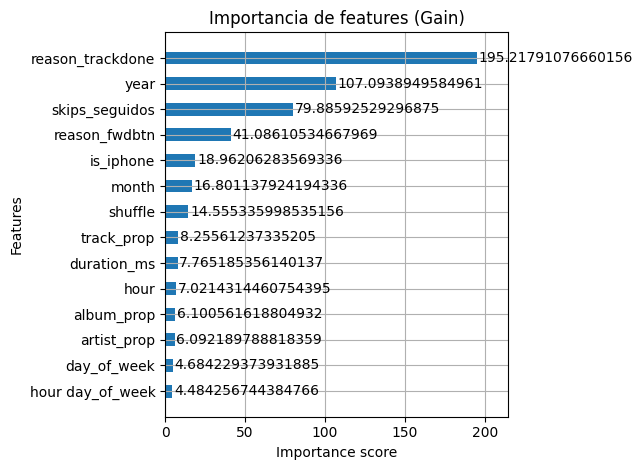

In [ ]:
import matplotlib.pyplot as plt
xgb.plot_importance(clf_xgb, importance_type='gain', max_num_features=20, height=0.5)
plt.title("Importancia de features (Gain)")
plt.tight_layout()
plt.show()

In [ ]:
# Predecimos sobre el conjunto de validación
best = clf_xgb.best_iteration
print(best)


prediccion_val = clf_xgb.predict_proba(val_data.drop(columns=['Unnamed: 0', 'ts','TARGET', 'master_metadata_track_name', 'master_metadata_album_artist_name', 'master_metadata_album_album_name', 'spotify_track_uri']))[:, 1]
auc = roc_auc_score(val_data['TARGET'], prediccion_val)
print(f"AUC-ROC: {auc:.4f}")

11
AUC-ROC: 0.9330


In [ ]:
prediccion_submmit = clf_xgb.predict_proba(submission.drop(columns=['Unnamed: 0', 'ts', 'master_metadata_track_name', 'master_metadata_album_artist_name', 'master_metadata_album_album_name', 'spotify_track_uri']))[:, 1]

In [ ]:
results = pd.DataFrame({'ID': submission['Unnamed: 0'], 'TARGET': prediccion_submmit})
results = results.set_index('ID').loc[submission_aux['Unnamed: 0']].reset_index()
results.to_csv('submission11.csv', index=False)